To use the radon operator the astra toolbox needs to be installed this is possible via 
```
conda install astra-toolbox -c astra-toolbox
```
for other methods see https://astra-toolbox.com/docs/install.html

also `scikit-image` needs to be installed


# Computer Tomography (CT) and Radon transform
+ absorbtion of Xray beams 
    + idelised no other interactions of xray beams and object that are not along the beams,
    + monocrimatic enrgy levels of beam
    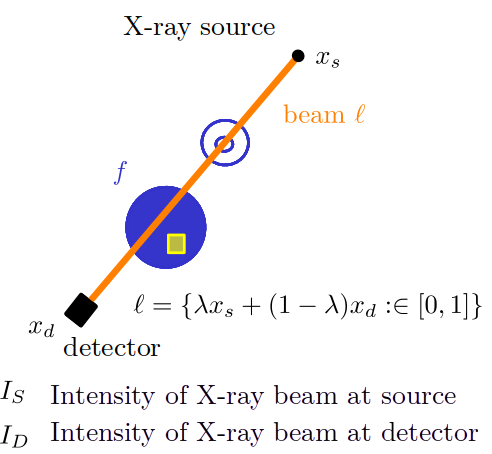

+ projection from multiple angles 
+ modeling via line intergrals 
$$
\log\left(\frac{I_S}{I_D}\right) = \int_\ell f(x) \text{d}x
$$
+ resulting of a linear operator 
$$
g(t,j) = \left(\int_{\ell_{t,j}} f(x) \text{d}x\right)_{(t,j)\in T\times D}
$$
+ There are muyltiple reconstruction Tecnices we will hre use algrothms to invert the linear operator



In [1]:
from examples.radon_transform.radon_astra import RadonAstra2D,RadonMatrixAstra2D
import numpy as np
import matplotlib.pyplot as plt
from skimage.data import shepp_logan_phantom
from skimage.transform import rescale

In [2]:
def Get2DBall(x,y,radius,x_res,y_res=None,inner_radius = 0):
    """creates a imige 2D of a ball around (x,y) with the radius,
      wich is 1 on the ball and 0 everywhere else.

    Args:
        x (float): x position of ball 
        y (float): y position of ball
        radius (float): radius in pixel count
        x_res (int): number of pixels in x diretion
        y_res (int, optional): number of pixels in y direction. Defaults to x_res.

    Returns:
        nparray: _description_
    """    
    if y_res is None:
        y_res = x_res

    ball = np.zeros((y_res,x_res))
    for i in range(y_res):
        for j in range(x_res):
            if inner_radius**2<=(i-x)**2+(j-y)**2<= radius**2:
                ball[i,j] = 1
    return ball



In [3]:
#creating the phantom
num_pix = 64 # Pixel number of one side of the square pahntom object, i.e. in total there are num_pix^2 pixel in the pahtom
phantome = shepp_logan_phantom() 
phantome = rescale(phantome, scale=num_pix/400, mode='reflect', channel_axis=None)
# ball_phant = Get2DBall(22.5,30.5,4,num_pix,inner_radius=3) + Get2DBall(22.5,30,8,num_pix,inner_radius=7)+Get2DBall(40.5,20,8,num_pix,inner_radius=0) - Get2DBall(43.5,23,2,num_pix,inner_radius=0)*0.2
# ball_phant = ball_phant * Get2DBall(num_pix/2-0.5,num_pix/2-0.5,num_pix/2,num_pix)
# phantome = ball_phant

Text(0.5, 1.0, 'phantome/object $f^\\dagger$')

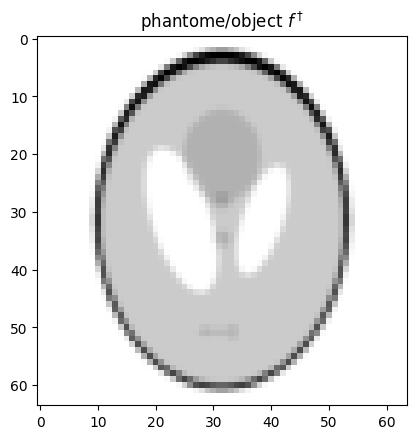

In [99]:
plt.imshow(phantome,"gray_r")
plt.title(r"phantome/object $f^\dagger$")

In [5]:
#setting the angles of measurmant (for parallelbeam half a rotoation is enough for cone beam more is needed)
angles = np.linspace(0,np.pi,num_pix,endpoint=False)

In [6]:
#Create a linear operator based on a sparse matrix created using the astra toolbox
#this gets memory intenive for larger num_pix,num_det,num_angles 
#it has dimension (num_det * num_angles) x (num_pix * num_pix)
op = RadonMatrixAstra2D(num_pix=num_pix,num_det=int(num_pix*np.sqrt(2)),
                  angles=angles,
                  geom_type="parallel",beam_type="strip",
                  source_to_origin=128,origin_to_detector=128,det_pix_len =1)


In [7]:
#Alternatily create a linear operator based on opeartors of the astra tolbox (this failes the adjoint test but thikonov works resonable well still). 
#It also is slower (on cpu) then saving the sparese matrix,
#but it has less start up time and is less memory intensive and the solvers are still working
# op = RadonAstra2D(num_pix=num_pix,num_det=int(num_pix*np.sqrt(2)),
#                   angles=angles,
#                   geom_type="parallel",beam_type="line",
#                   source_to_origin=128,origin_to_detector=128,det_pix_len =1)

[Text(0, 0, '0'), Text(32, 0, '90'), Text(63, 0, '177')]

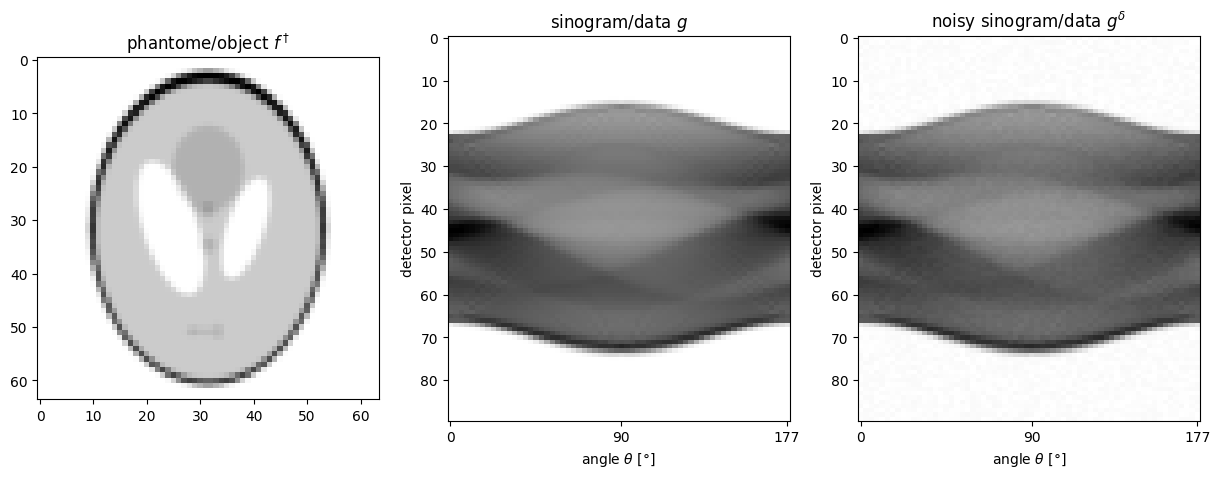

In [20]:
sino= op(phantome)
noise = op.codomain.rand()*2-1
noise = noise/np.linalg.norm(sino.flatten())
#set noise level delta
delta = 0.2
sino_noisy = sino + np.linalg.norm(sino.flatten())*noise *delta


#plot phantom and sinograms
fig,axs = plt.subplots(1,3,figsize = (15,5))
ax = axs[0]
ax.imshow(phantome,"gray_r")
ax.set_title(r"phantome/object $f^\dagger$reco_square_nonneg")
# ax.set_axis_off()
ax = axs[1]
ax.imshow(sino,"gray_r",aspect="auto")
ax.set_title(r'sinogram/data $g$' )
ax.set_xlabel(r"angle $\theta$ [°]")
ax.set_ylabel("detector pixel")
ids = np.arange(len(angles))[[0,int(len(angles)/2),-1]]
ax.set_xticks(ids)
ax.set_xticklabels(np.round(angles[ids]/np.pi*180).astype(int))

ax = axs[2]
ax.imshow(sino_noisy,"gray_r",aspect="auto")
ax.set_title(r'noisy sinogram/data $g^\delta$' )
ax.set_xlabel(r"angle $\theta$ [°]")
ax.set_ylabel("detector pixel")
ids = np.arange(len(angles))[[0,int(len(angles)/2),-1]]
ax.set_xticks(ids)
ax.set_xticklabels(np.round(angles[ids]/np.pi*180).astype(int))

In [21]:
from regpy.solvers import RegularizationSetting
import regpy.stoprules as rules
from regpy.hilbert import L2
# from regpy.functionals import L1
from regpy.solvers.linear.tikhonov import TikhonovCG

In [22]:
#Adjusting the progress output of the solvers
import logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s %(levelname)s %(name)-40s :: %(message)s'
)

For Reconstruction we will now use the folowing Thikhonov minimisation problem  
$$
\arg\min_{f\in X}\Vert Af-g \Vert_2^2 + \alpha\Vert f \Vert_2^2
$$
using the `TikhonovCG` solver

In [100]:
stoprule = (
    rules.CountIterations(max_iterations=1000)
)
setting = RegularizationSetting(op,L2,L2)

alpha = 0.1
solver = TikhonovCG(setting,sino_noisy,alpha)
reco_square, reco_data = solver.run(stoprule)


2024-10-14 11:36:56,939 INFO CountIterations      :: iteration = 1 / 1000
2024-10-14 11:36:56,943 INFO CountIterations      :: iteration = 2 / 1000
2024-10-14 11:36:56,946 INFO CountIterations      :: iteration = 3 / 1000
2024-10-14 11:36:56,949 INFO CountIterations      :: iteration = 4 / 1000
2024-10-14 11:36:56,951 INFO CountIterations      :: iteration = 5 / 1000
2024-10-14 11:36:56,955 INFO CountIterations      :: iteration = 6 / 1000
2024-10-14 11:36:56,958 INFO CountIterations      :: iteration = 7 / 1000
2024-10-14 11:36:56,962 INFO CountIterations      :: iteration = 8 / 1000
2024-10-14 11:36:56,966 INFO CountIterations      :: iteration = 9 / 1000
2024-10-14 11:36:56,970 INFO CountIterations      :: iteration = 10 / 1000
2024-10-14 11:36:56,975 INFO CountIterations      :: iteration = 11 / 1000
2024-10-14 11:36:56,980 INFO CountIterations      :: iteration = 12 / 1000
2024-10-14 11:36:56,984 INFO CountIterations      :: iteration = 13 / 1000
2024-10-14 11:36:56,990 INFO Tikho

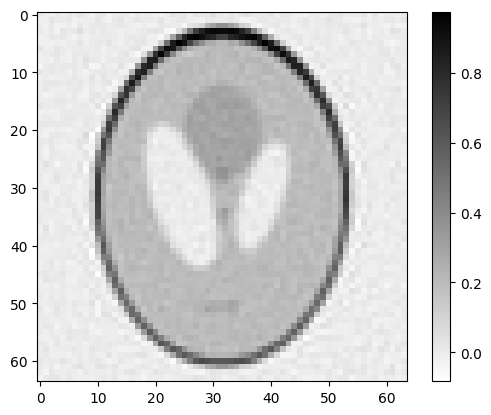

In [101]:

plt.figure()
plt.imshow(reco_square,"gray_r")
plt.colorbar()

### Other regularisation
We want to look at different regolaristaion terms, to enforce a physikaly plausible solution we want to enforce nonegatifity of the solution, i.e. we want to use the indicator fuction
$$
\xi_{X_{\geq0}}(f):= 
\begin{cases}
0 &\text{ if } f_{i}\geq0 \forall i \\
\infty &\text{ else.}
\end{cases}
$$
The minimisation problem we now want to solve is
$$
\arg\min_{f\in X}\Vert Af-g \Vert_2^2 + \xi_{X_{\geq}}(f).
$$
To solve this we will use the `DouglasRachford` solver, to use it we need the proximal operators of the regularisation/penalty term.

In [102]:
from regpy.solvers.linear.primal_dual import PDHG,DouglasRachford
from regpy.functionals import L1Generic,L1MeasureSpace,Functional,QuadraticNonneg
from regpy.functionals import HilbertNorm, TVUniformGridFcts

In [134]:
class Nonneg(Functional):
    def __init__(self, domain, h_domain=None, linear=False):
        super().__init__(domain, h_domain, linear)

    def _eval(self, x):
        if (x<0).any():
            return np.infty
        else:
            return 0
    
    def proximal(self, x, tau, recursion_safeguard=False):
        return np.maximum(x,0)

In [143]:
data = sino_noisy
init = op.domain.ones()
setting = RegularizationSetting(op,
                                penalty=Nonneg(op.domain),
                                data_fid=HilbertNorm(h_space=L2) * (op - data)
                                )
stoprule = (
    rules.CountIterations(max_iterations=100)+
    rules.Discrepancy(setting.h_codomain.norm, data,delta*np.linalg.norm(sino_noisy),1)
            )
solver = DouglasRachford(setting,init,tau = 1,regpar=1)
reco_nonneg, reco_data = solver.run(stoprule)

2024-10-14 11:49:58,993 INFO CountIterations      :: iteration = 1 / 100
2024-10-14 11:49:58,994 INFO Discrepancy          :: relative discrepancy = 6.76, tolerance = 1.00
2024-10-14 11:49:59,008 INFO TikhonovCG           :: it.6 kappa=1.4568155882101634 err/Tol rel X:5.9e-01/9.1e-01 
2024-10-14 11:49:59,009 INFO TikhonovCG           :: Solver converged after 6 iteration.
2024-10-14 11:49:59,011 INFO CountIterations      :: iteration = 2 / 100
2024-10-14 11:49:59,011 INFO Discrepancy          :: relative discrepancy = 0.07, tolerance = 1.00
2024-10-14 11:49:59,012 INFO CombineRules         :: Rule Discrepancy(noiselevel=113.6973645565058, tau=1) triggered.
2024-10-14 11:49:59,012 INFO DouglasRachford      :: Solver converged after 1 iteration.


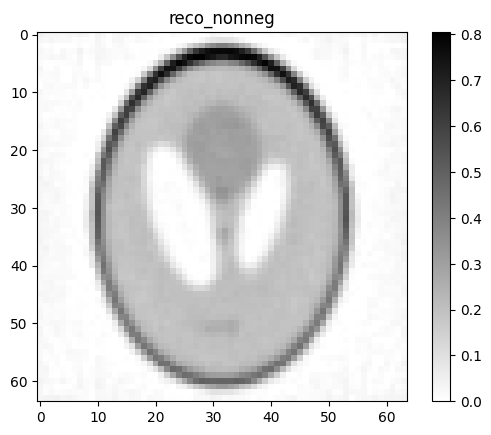

In [144]:
plt.figure()
plt.imshow(reco_nonneg,cmap="gray_r")
plt.title("reco_nonneg")
plt.colorbar()

Combing the two penalty terms above results in
the minimisation problem
$$
\arg\min_{f\in X}\Vert Af-g \Vert_2^2 + \begin{cases}
F(x) = 1/2 |x|^2 &\text{if } x\geq 0\\
F(x) = \infty &\text{if } x<0
\end{cases}.
$$


In [184]:
data = sino_noisy
init = op.domain.ones()*0
setting = RegularizationSetting(op,
                                penalty=QuadraticNonneg,
                                data_fid=HilbertNorm(h_space=L2) * (op - data)
                                )
stoprule = (
    rules.CountIterations(max_iterations=100)+
    rules.Discrepancy(setting.h_codomain.norm, data,delta*np.linalg.norm(sino_noisy),1)
            )
solver = DouglasRachford(setting,init,tau = .1,regpar=1)
reco_square_nonneg, reco_data = solver.run(stoprule)

2024-10-14 12:01:35,097 INFO CountIterations      :: iteration = 1 / 100
2024-10-14 12:01:35,098 INFO Discrepancy          :: relative discrepancy = 1.11, tolerance = 1.00
2024-10-14 12:01:35,136 INFO TikhonovCG           :: it.13 kappa=1.954973291865201 err/Tol rel X:7.6e-01/9.7e-01 
2024-10-14 12:01:35,136 INFO TikhonovCG           :: Solver converged after 13 iteration.
2024-10-14 12:01:35,137 INFO CountIterations      :: iteration = 2 / 100
2024-10-14 12:01:35,138 INFO Discrepancy          :: relative discrepancy = 0.09, tolerance = 1.00
2024-10-14 12:01:35,138 INFO CombineRules         :: Rule Discrepancy(noiselevel=113.6973645565058, tau=1) triggered.
2024-10-14 12:01:35,138 INFO DouglasRachford      :: Solver converged after 1 iteration.


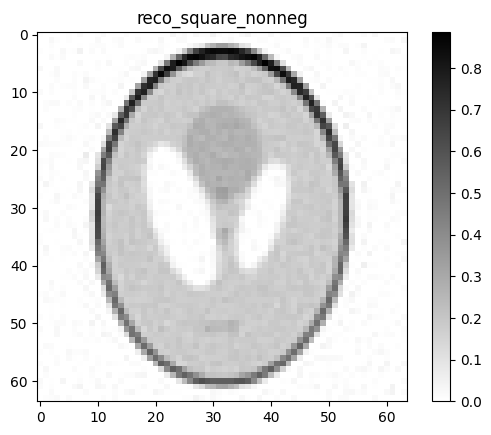

In [185]:
plt.figure()
plt.imshow(reco_square_nonneg,cmap="gray_r")
plt.title("reco_square_nonneg")
plt.colorbar()

The L1 norm is also a common penalty term, if a suitable object is expected
$$
\arg\min_{f\in X}\Vert Af-g \Vert_2^2 + \alpha\Vert f \Vert_1
$$

In [186]:
data = sino_noisy
init = op.domain.ones()*0
setting = RegularizationSetting(op,
                                penalty= L1Generic(op.domain),
                                data_fid=HilbertNorm(h_space=L2) * (op - data)
                                )
stoprule = (
    rules.CountIterations(max_iterations=100)+
    rules.Discrepancy(setting.h_codomain.norm, data,delta*np.linalg.norm(sino_noisy),1)
            )
solver = DouglasRachford(setting,init,tau = 0.05,regpar=1)
reco_L1, reco_data = solver.run(stoprule)

2024-10-14 12:01:37,159 INFO CountIterations      :: iteration = 1 / 100
2024-10-14 12:01:37,160 INFO Discrepancy          :: relative discrepancy = 1.11, tolerance = 1.00
2024-10-14 12:01:37,196 INFO TikhonovCG           :: it.17 kappa=3.355213095665449 err/Tol rel X:8.3e-01/9.8e-01 
2024-10-14 12:01:37,197 INFO TikhonovCG           :: Solver converged after 17 iteration.
2024-10-14 12:01:37,200 INFO CountIterations      :: iteration = 2 / 100
2024-10-14 12:01:37,201 INFO Discrepancy          :: relative discrepancy = 0.21, tolerance = 1.00
2024-10-14 12:01:37,202 INFO CombineRules         :: Rule Discrepancy(noiselevel=113.6973645565058, tau=1) triggered.
2024-10-14 12:01:37,202 INFO DouglasRachford      :: Solver converged after 1 iteration.


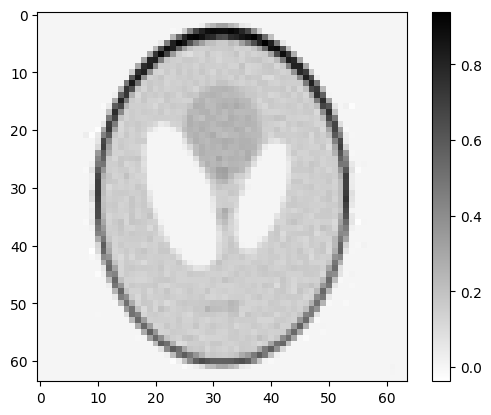

In [187]:
plt.figure()
plt.imshow(reco_L1,cmap="gray_r")
plt.colorbar()

Plot all reconstructions for comparison for comparisoon

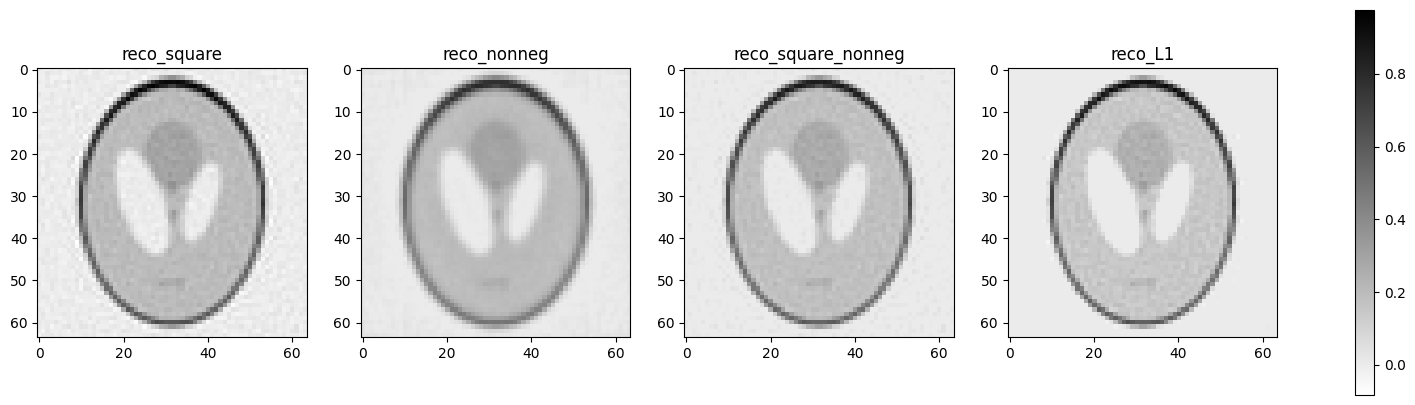

In [188]:
recos_dic = {"reco_square":reco_square,
             "reco_nonneg":reco_nonneg,
             "reco_square_nonneg":reco_square_nonneg,
             "reco_L1":reco_L1,
             }
vmin = min([np.min(recos_dic[key]) for key in recos_dic.keys()])
vmax = max([np.max(recos_dic[key]) for key in recos_dic.keys()])
fig,axs = plt.subplots(1,4,figsize = (20,5))
for ax,key in zip(axs,recos_dic):
    im = ax.imshow(recos_dic[key],"gray_r",vmin=vmin,vmax=vmax)
    ax.set_title(key)
fig.colorbar(im,ax=axs)